# 03MIAR - Algoritmos de optimización
## Actividad guiada 2

*Arrate Bello Martija*

URL DE GITHUB: 

## Presentación

Profesor:
- Grupos A2, A3, B1, B2: David Álvarez Robles (dalvarezr@professor.universidadviu.com)

## Objetivos
- Comprender la utilidad y aplicar algoritmos dinámicos
- Comprender la utilidad y aplicar algoritmos de ramificación y poda
- Comprender la utilidad y aplicar el algoritmo de optimización por descenso de gradiente

## Programación dinámica - Problema del viaje por el río
- Se divide el problema en subproblemas más pequeños para poder usar las soluciones más adelante
- Si el problema verifica el principio de optimalidad de Bellman "en una secuencia óptima de decisiones, toda sub-secuencia es también óptima" esto funciona bien
- Guardar soluciones parciales + recursividad = complejidad

In [1]:
import math

i = float("inf") # daremos un valor infinito si no es posible ir desde i a j

tarifas = [ # cada número quiere decir el precio para ir del nodo i (fila) al nodo j (columna)
    [0, 5, 4, 3, i, i, i],
    [i, 0, i, 2, 3, i, 11],
    [i, i, 0, 1, i, 4, 10],
    [i, i, i, 0, 5, 6, 9],
    [i, i, i, i, 0, i ,4],
    [i, i, i, i, i, 0, 3],
    [i, i, i, i, i, i, 0]
] # valores de debajo de la diagonal son infinitos, porque no se puede volver hacia atrás


# Función para obtener precios finales entre dos nodos y qué rutas seguir
def obtener_precios_y_rutas(tarifas):
    # Inicialización de tabla de precios y rutas (precios a infinito como peor caso)
    nodos = len(tarifas[0])
    precios = [[i]*nodos for i in [float("inf")]*nodos]
    ruta = [[i]*nodos for i in [""]*nodos]

    # Recorremos todos los caminos (desde "n" hasta un "n" superior -> Ej: 0 a 1, 0 a 2, 1 a 4... pero nunca de 1 a 0 o de 4 a 2)
    for i in range(nodos-1):
        for j in range(i+1,nodos):

            # Asumimos que el mínimo es la tarifa de un nodo a otro inicialmente
            minimo = tarifas[i][j]
            # Asumimos que la mejor ruta de un nodo a otro comienza en el nodo inicial (ej: 0,1 -> 0, 0,4 -> 0, 2,5 -> 2)
            ruta[i][j] = i

            # Recorremos posibles movimientos intermedios
            for k in range(i,j): 
                #print(precios)
                #print(f"i: {i}, j: {j}, k: {k}, precios_ik: {precios[i][k]}, tarifas_kj: {tarifas[k][j]}")
                # Si el precio de ir de i a k más la tarifa de k a j es menor que la tarifa de i a j, nos quedamos con esa ruta
                if (precios[i][k] + tarifas[k][j] < minimo):
                    minimo = precios[i][k] + tarifas[k][j] # actualizamos 
                    ruta[i][j] = k # ahora en lugar de ir directo, es a través del nodo intermedio k
                # Actualizamos precio de i a j como el mínimo (puede ser pasando por k)
                precios[i][j] = minimo

    # Retornamos tabla de precios y de rutas de un nodo a otro
    return precios, ruta

# Función que calcula la ruta óptima a seguir
def calcular_ruta(ruta, inicio, fin, resultado = []):
    # Si el nodo inicial es igual al final, devolvemos el nodo
    if inicio == fin:
        #print(f"{inicio}")
        resultado.append(inicio)
        return resultado
    # Si tengo que desplazarme, calculo recursivamente la ruta de inicio a final siguiendo la tabla de rutas
    else:
        #print(f"{fin}")
        resultado.append(fin)
        return calcular_ruta(ruta, inicio, ruta[inicio][fin])

precios, ruta = obtener_precios_y_rutas(tarifas)

for fila in precios:
  print(fila)
print("---")
for fila in ruta:
  print(fila)

desde=0
hasta=6
resultado = calcular_ruta(ruta, desde, hasta)
print("---")
print(f"Ruta a seguir: {resultado[::-1]}")

[inf, 5, 4, 3, 8, 8, 11]
[inf, inf, inf, 2, 3, 8, 7]
[inf, inf, inf, 1, 6, 4, 7]
[inf, inf, inf, inf, 5, 6, 9]
[inf, inf, inf, inf, inf, inf, 4]
[inf, inf, inf, inf, inf, inf, 3]
[inf, inf, inf, inf, inf, inf, inf]
---
['', 0, 0, 0, 1, 2, 5]
['', '', 1, 1, 1, 3, 4]
['', '', '', 2, 3, 2, 5]
['', '', '', '', 3, 3, 3]
['', '', '', '', '', 4, 4]
['', '', '', '', '', '', 5]
['', '', '', '', '', '', '']
---
Ruta a seguir: [0, 2, 5, 6]


## Ramificación y poda - Problema de las tareas
- Se necesitan funciones auxiliares para calcular todo el grafo (árbol)
- Función para calcular costes de soluciones parciales (no completas)
- Función para calcular cota inferior (muy optimista, repitiendo tareas si es necesario aunque la poda sea peor)
- Función para crear hijos e ir construyendo las soluciones
- Función para ramificar nodos y podar

El problema consiste en maximizar el rendimiento (o minimizar los costes) en cuanto a la asignación de N tareas a N agentes. Cada tarea solo puede ser asignado a un agente. En este caso, tenemos 4 agentes y 4 tareas.

In [2]:
import itertools
import math

# matriz de costes: a_ij es el coste de asignar la tarea j al agente i
costes = [
    [11,12,18,40],
    [14,15,13,22],
    [11,17,19,23],
    [17,14,20,28]
] 

# for s in itertools.permutations(range(len(costes))):
  # print(s)

In [3]:
def fuerza_bruta(costes):

    optimo = float("inf") # al principio coste infinito 

    for s in itertools.permutations(range(len(costes))): # recorrer todas las soluciones posibles
        coste = sum(costes[i][s[i]] for i in range(len(costes))) # Acumulo costes de cada agente
        if (coste < optimo):
            tareas, optimo = s, coste

    return tareas, optimo

tareas, optimo = fuerza_bruta(costes)
print(f"Obtenida mejor solución {tareas} con coste {optimo} por fuerza bruta.")

Obtenida mejor solución (0, 2, 3, 1) con coste 61 por fuerza bruta.


In [4]:
# Esta función calcula el coste de la solución parcial
def coste_parcial(solucion, costes):
    coste = 0

    for i in range(len(solucion)):
        coste += costes[i][solucion[i]]

    return coste

#coste = coste_parcial((0,1),costes) # 11 + 15 = 26
#print(coste)

In [5]:
# Esta función calcula la cota inferior de la solución parcial (repitiendo tareas si es necesario)
def cota_inferior(solucion, costes):

    # Calculo el coste parcial de la solución dada (la solución hasta ahora)
    coste = coste_parcial(solucion,costes)

    # Calculo coste mínimo de opciones restantes no usadas permitiendo reutilización por sencillez (relajación = menos poda)
    no_usadas = set(range(len(costes)))-set(solucion) # tareas NO asignadas

    for i in range(len(solucion),len(costes)): # recorremos los agentes que no tienen tarea asignada
        coste += min([costes[i][j] for j in no_usadas]) # cada agente coge su mejor tarea (aunque se repita)

    return coste

#CI = cota_inferior((0,1),costes)
#print(CI)

El cálculo de la cota no puede ser muy complejo, porque esto influiría en la complejidad del algoritmo. 

In [6]:
# def cota_superior(solucion, costes):
#     # Calculo el coste parcial de la solución dada
#     coste = coste_parcial(solucion,costes)

#     # Calculo coste máximo de opciones restantes no usadas
#     no_usadas = set(range(len(costes)))-set(solucion)

#     for i in range(len(solucion),len(costes)):
#         coste += max([costes[i][j] for j in no_usadas])

#     return coste

# CS = cota_superior((0,1),costes)
# print(CS)

In [7]:
# Función para crear las ramas del árbol
def crear_hijos(solucion, dimension):
  hijos = []
  for i in range(dimension):
    if i not in solucion:
      hijos.append({'s':solucion + (i,)})
  return hijos

# crear_hijos((0,1),4)

In [8]:
def ramificacion_y_poda(costes):

    # primero calculamos la dimensión del problema
    dimension = len(costes)

    # Inicializo solución a vacío con el peor coste posible
    mejor_solucion = tuple(i for i in range(dimension))
    mejor_coste = coste_parcial(mejor_solucion,costes)

    # Creo un array de nodos y lo inicializo con una solución vacía (para comenzar por algo)
    nodos = []
    nodos.append({'s':(), 'ci':cota_inferior((),costes)})
    # print(nodos)

    # Llevo cuenta de iteraciones por debugging
    iteracion = 0

    # Mientras haya nodos por explorar, aplico ramificación y poda
    while(nodos):
        # Cojo el nodo más prometedor (menor cota inferior, aunque esto luego puede ser "peor" a posteriori)
        nodo = min(nodos, key=lambda x: x['ci'])
        #print(nodo)
        
        # Ramifico el nodo para obtener sus hijos
        hijos = crear_hijos(nodo['s'],dimension)

        # Para cada hijo, hago el procesamiento adecuado antes de decidir si es solución completa o un nuevo nodo
        for hijo in hijos:

            # Si la dimensión de la solución es igual a la dimensión de costes, es una solución final
            if (len(hijo['s']) == dimension):
                # Calculo el coste de la solución obtenida en el árbol
                coste = coste_parcial(hijo['s'],costes)
                # Si el coste es mejor, me lo quedo como solución
                if (coste < mejor_coste):
                    mejor_solucion = hijo['s']
                    mejor_coste = coste

            # Si la dimensión de la solución no es igual a la dimensión de costes, aplico poda
            else:
                # Calculo cota inferior del hijo
                cota_inferior_hijo = cota_inferior(hijo['s'], costes)
                # Si la cota inferior es menor que el mejor coste, lo añado a la lista de nodos a actualizar
                # Si la cota inferior fuera mayor, no tiene sentido porque no puede mejorar mi solución -> Poda
                if (cota_inferior_hijo <= mejor_coste):
                    nodos.append({'s':hijo['s'], 'ci':cota_inferior_hijo})
                #else:
                    #print(mejor_coste)
                    #print(f"Nodo eliminado: {hijo['s']} con cota inferior {cota_inferior_hijo}")

        # Elimino el nodo ya mirado
        nodos.remove(nodo)

        # Llevo la cuenta de las iteraciones que hago
        iteracion += 1

    return iteracion, mejor_solucion, mejor_coste

iteraciones, mejor_solucion, mejor_coste = ramificacion_y_poda(costes)
print(f"Obtenida mejor solución {mejor_solucion} con coste {mejor_coste} en {iteraciones} iteraciones")

Obtenida mejor solución (0, 2, 3, 1) con coste 61 en 17 iteraciones


## Descenso del gradiente - Optimización de funciones
- Se lleva a cabo una optimización basada en el método del descenso de gradiente
- Se calcula el vector de derivadas parciales y se minimiza la función objetivo actualizando los nuevos puntos (ver figura)

El procedimiento del descenso del gradiente parte de un punto $p$ como solución aproximada y da pasos en el sentido opuesto al gradiente (si minimizamos) de la función en dicho punto. 
$$ p_{t+1}=p_{t}-\alpha_{t}\nabla f(p_{t}), \text{ donde el parámetro } \alpha_{t} \text{ (tasa de aprendizaje) se selecciona para que } p_{t+1} \text{ sea solución y }  f(p_{t}) \geq  f(p_{t+1}).   $$

Solución: [-1.1208004332814762e-111, 5.239871588801792e-112] 
Valor de la función en la solución: 1.530756153915267e-222


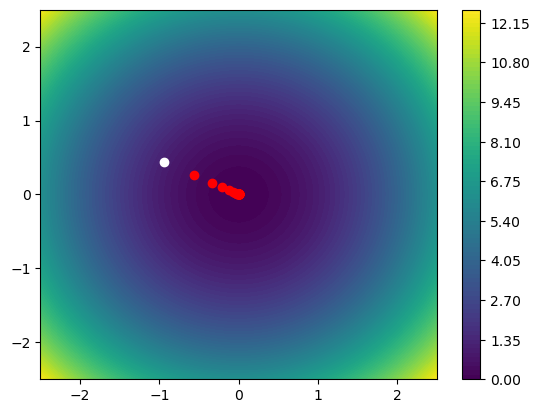

In [9]:
import math
import matplotlib.pyplot as plt
import numpy as np
import random

f = lambda X : X[0]**2 + X[1]**2 # x^2 + y^2 función
df = lambda X : [2*X[0] , 2*X[1]] # (2x, 2y) gradiente (derivada de la función con respecto a cada variable)

resolucion = 100
rango = 2.5
X = np.linspace(-rango, rango, resolucion)
Y = np.linspace(-rango, rango, resolucion)
Z = np.zeros([resolucion, resolucion])

for ix, x in enumerate(X):
    for iy, y in enumerate(Y):
        Z[ix,iy] = f([x,y])

plt.contourf(X, Y, Z, resolucion)
plt.colorbar()

P = [random.uniform(-2,2), random.uniform(-2,2)] #punto cualquiera dentro del rango
plt.plot(P[0],P[1],"o",c="white")

tasa_aprendizaje = 0.2
for _ in range(500):
    grad = df(P)
    P[0], P[1] = P[0] - tasa_aprendizaje*grad[0], P[1] - tasa_aprendizaje*grad[1]
    plt.plot(P[0],P[1],"o",c="red")

print("Solución:", P, "\nValor de la función en la solución:", f(P))

El mínimo es aproximadamente (0,0).

## Actividades extra

- Ramificación y poda
  - Generar matrices con valores aleatorios de mayores dimensiones (5,6,7,…) y ejecutar ambos algoritmos.
  - ¿A partir de que dimensión el algoritmo por fuerza bruta deja de ser una opción?
  - ¿Hay algún valor de la dimensión a partir de la cual el algoritmo de ramificación y poda también deja de ser una opción válida?

In [10]:
import time

def fuerza_bruta_2(costes, limite_segundos):

    inicio = time.time() # inicializamos el tiempo
    optimo = float("inf")
    tareas = None
    
    for s in itertools.permutations(range(len(costes))):
        
        if time.time() - inicio > limite_segundos:
            return -1 # Corta si se pasa del tiempo
        
        coste = sum(costes[i][s[i]] for i in range(len(costes)))
        if (coste < optimo):
            tareas, optimo = s, coste

    return time.time() - inicio # devuelve los segundos que ha tardado en encontrar la solución óptima


# Bucle para ir aumentando la dimensión del problema 
limite = 120 # segundos máximos antes de parar

for n in range(5, 20):
    random.seed(50) # fijamos la semilla para generar las mismas matrices para ambos algoritmos
    costes = [[random.randint(1, 100) for _ in range(n)] for _ in range(n)] # generar matrices 
    tiempo = fuerza_bruta_2(costes, limite)
    
    if tiempo == -1:
        print(f"N={n} -> Límite de tiempo superado.")
        break
    else:
        print(f"N={n} -> {tiempo:.4f} segundos")

N=5 -> 0.0001 segundos
N=6 -> 0.0007 segundos
N=7 -> 0.0054 segundos
N=8 -> 0.0403 segundos
N=9 -> 0.4038 segundos
N=10 -> 4.8439 segundos
N=11 -> 49.9772 segundos
N=12 -> Límite de tiempo superado.


La complejidad temporal del algoritmo por fuerza bruta crece de forma factorial $O(n!)$, asique podríamos concluir que este algortimo deja de ser una opción viable a partir de $N=11$. Para $N=12$, evaluaría 479 millones de combinaciones y dispararía el tiempo de procesamiento a aproximadamente 16 minutos. 

In [11]:
def ramificacion_y_poda_2(costes, limite_segundos):
    inicio = time.time()
    dimension = len(costes)

    mejor_solucion = tuple(i for i in range(dimension))
    mejor_coste = coste_parcial(mejor_solucion, costes)

    nodos = []
    nodos.append({'s':(), 'ci':cota_inferior((),costes)})

    while(nodos):
        
        if time.time() - inicio > limite_segundos:
            return -1 # corta si se pasa del tiempo
    

        nodo = min(nodos, key=lambda x: x['ci'])
        hijos = crear_hijos(nodo['s'], dimension)

        for hijo in hijos:
            if (len(hijo['s']) == dimension):
                coste = coste_parcial(hijo['s'], costes)
                if (coste < mejor_coste):
                    mejor_solucion = hijo['s']
                    mejor_coste = coste
            else:
                cota_inferior_hijo = cota_inferior(hijo['s'], costes)
                if (cota_inferior_hijo <= mejor_coste):
                    nodos.append({'s':hijo['s'], 'ci':cota_inferior_hijo})

        nodos.remove(nodo)

    return time.time() - inicio # devuelve los segundos que ha tardado


# Bucle
limite = 120

for n in range(5, 40): 
    random.seed(50) 
    costes = [[random.randint(1, 100) for _ in range(n)] for _ in range(n)]
    tiempo = ramificacion_y_poda_2(costes, limite)
    
    if tiempo == -1:
        print(f"N={n} -> Límite de tiempo superado.")
        break
    else:
        print(f"N={n} -> {tiempo:.4f} segundos")

N=5 -> 0.0002 segundos
N=6 -> 0.0008 segundos
N=7 -> 0.0233 segundos
N=8 -> 0.0008 segundos
N=9 -> 0.0017 segundos
N=10 -> 0.1838 segundos
N=11 -> 0.0075 segundos
N=12 -> 0.4597 segundos
N=13 -> 3.6743 segundos
N=14 -> 0.2254 segundos
N=15 -> 0.1585 segundos
N=16 -> 1.4767 segundos
N=17 -> Límite de tiempo superado.


El algoritmo de ramificación y poda mejora mucho el tiempo respecto a la fuerza bruta, ya que descarta ramas del árbol que no pueden mejorar la mejor solución encontrada hasta el momento. Sin embargo, en el peor caso la cota inferior utilizada poda poco, y el número de nodos que sobreviven puede seguir creciendo de forma muy rápida. Por eso los tiempos no crecen de forma monótona, estos dependen mucho de la matriz de costes concreta que se genere en cada iteración (para algunos valores de $N$ la cota poda casi todo el árbol y el algoritmo es casi instantáneo, y para otros el árbol que sobrevive es mucho más grande). De hecho, si en lugar de fijar la semilla en `random.seed(50)` se usa `random.seed(n)` (una semilla distinta para cada $N$), el límite de tiempo se supera ya en $N=13$ (ver siguiente celda), lo que confirma que el factor determinante no es tanto $N$ como la estructura concreta de la matriz generada. En las pruebas realizadas, el algoritmo deja de ser viable (supera el límite de tiempo establecido) a partir de aproximadamente $N=17$, aunque este valor concreto puede variar de una ejecución a otra porque depende de los valores aleatorios de la matriz. En cualquier caso, el rango en el que sigue siendo útil es mucho mayor que en fuerza bruta, lo cual demuestra la utilidad de la poda.

In [12]:
n=13
random.seed(n)
costes = [[random.randint(1, 100) for _ in range(n)] for _ in range(n)]
ramificacion_y_poda_2(costes, limite)

-1

- Descenso de gradiente
  - Minimizar la función sin(1/2 * x^2 - 1/4 * y^2 + 3) * cos(2*x + 1 - E^y)

Mejor punto inicial: -1.7548075530101181 0.0561142628634157
Mejor solución encontrada: [np.float64(-2.0276506179837224), np.float64(1.1718268362346183)]
Mejor valor de f(P): -1.0


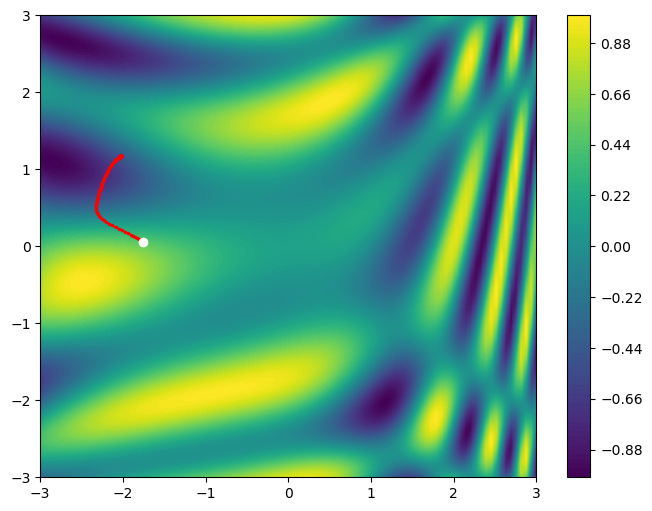

In [13]:
f = lambda X: np.sin(0.5 * X[0]**2 - 0.25 * X[1]**2 + 3) * np.cos(2 * X[0] + 1 - np.exp(X[1])) # función

# gradiente 
def df(X): 
    x, y = X[0], X[1]
    u = 0.5 * x**2 - 0.25 * y**2 + 3
    v = 2 * x + 1 - np.exp(y)
    d_x = x * np.cos(u) * np.cos(v) - 2 * np.sin(u) * np.sin(v)
    d_y = -0.5 * y * np.cos(u) * np.cos(v) + np.exp(y) * np.sin(u) * np.sin(v)
    return [d_x, d_y]


resolucion = 100
rango = 3
X = np.linspace(-rango, rango, resolucion)
Y = np.linspace(-rango, rango, resolucion)
Z = np.zeros([resolucion, resolucion])

for ix, x in enumerate(X):
    for iy, y in enumerate(Y):
        Z[ix, iy] = f([x, y])

mejor_f = float('inf')
mejor_P = None
mejor_trayectoria_x = []
mejor_trayectoria_y = []

# Bucle de 20 puntos aleatorios
for _ in range(20):
    P = [random.uniform(-2, 2), random.uniform(-1, 1)]
    tasa_aprendizaje = 0.02
    tray_x = [P[0]]
    tray_y = [P[1]]
    for _ in range(300):
        grad = df(P)
        P[0] = P[0] - tasa_aprendizaje * grad[0]
        P[1] = P[1] - tasa_aprendizaje * grad[1]
        tray_x.append(P[0])
        tray_y.append(P[1])
        
    valor_actual = f(P)
    
    # nos quedamos con el que consiga el valor más bajo de la función
    if valor_actual < mejor_f:
        mejor_f = valor_actual
        mejor_P = P
        mejor_trayectoria_x = tray_x
        mejor_trayectoria_y = tray_y

print("Mejor punto inicial:", mejor_trayectoria_x[0], mejor_trayectoria_y[0])
print("Mejor solución encontrada:", mejor_P)
print("Mejor valor de f(P):", mejor_f)

plt.figure(figsize=(8, 6))
plt.contourf(X, Y, Z, resolucion)
plt.colorbar()

plt.plot(mejor_trayectoria_x, mejor_trayectoria_y, "r.-", linewidth=1.5, markersize=3, label="Mejor Trayectoria")
plt.plot(mejor_trayectoria_x[0], mejor_trayectoria_y[0], "o", c="white") # punto inicial
plt.show()

Implementamos el algoritmo del descenso del gradiente para 20 puntos aleatorios distintos. De esta forma, evitamos que el descenso del gradiente se quede atrapado en el primer mínimo local que encuentra y seleccionamos automáticamente la trayectoria que alcanza el valor más bajo de la función.